In [1]:
from common_setup import *

In [2]:
import numpy as np
from scipy.optimize import minimize
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import ShuffleSplit
from typing import Tuple, List

def make_polynomial_features(X: np.ndarray, order: int) -> np.ndarray:
    """
    Generate polynomial features up to 'order'.
    If order=1, we get [1, x1, x2, ...].
    If order=2, we get [1, x1, x2, ..., x1^2, x1*x2, ...].
    """
    if order < 1 or order > 2:
        raise ValueError("Only order=1 or order=2 are supported.")
    
    poly = PolynomialFeatures(degree=order, include_bias=True)
    # shape: (n_samples, number_of_poly_features)
    return poly.fit_transform(X)


def sigmoid(s1,s2):
    diff=s1-s2
    ratio_pred=1.0/(1.0+np.exp(-diff))-0.5
    return ratio_pred

def inv_sigmoid(ratio_pred):
    return np.log((ratio_pred + 0.5) / (0.5 - ratio_pred))

def fit_definite_strength_poly(
    X1: np.ndarray,
    X2: np.ndarray,
    y: np.ndarray,
    order: int = 1,
    alpha: List[float] = None,
    w_init: np.ndarray = None
) -> np.ndarray:
    if alpha is None:
        # Default: no regularization if not specified
        alpha = [0.0] * (2 if order == 1 else 3)
    
    if order == 1 and len(alpha) != 2:
        raise ValueError("For order=1, alpha must have length=2.")
    if order == 2 and len(alpha) != 3:
        raise ValueError("For order=2, alpha must have length=3.")
    
    # Transform X1, X2 to polynomial features
    Z1 = make_polynomial_features(X1, order)  # shape: (n_samples, n_poly_features)
    Z2 = make_polynomial_features(X2, order)  # same shape
    n_samples, n_poly_features = Z1.shape
    
    d = X1.shape[1]
    intercept_idx = [0]
    linear_idx = list(range(1, d+1))
    if order == 1:
        quadratic_idx = []
    else:
        quadratic_idx = list(range(d+1, n_poly_features))
    
    alpha0 = alpha[0]  # intercept
    alpha1 = alpha[1]  # linear
    alpha2 = alpha[2] if order == 2 else 0.0  # quadratic (only if order=2)

    # Initial guess
    if w_init is None:
        w_init = np.zeros(n_poly_features)#np.random.randn(n_poly_features)

    def objective(w):
        # Predictions for each sample pair
        s1 = Z1.dot(w)  # shape: (n_samples,)
        s2 = Z2.dot(w)

        ratio_pred = sigmoid(s1,s2)  # shape: (n_samples,)
        # sum of squared errors
        residuals = y - ratio_pred
        sse = np.sum(residuals**2)

        # Regularization
        reg_intercept = alpha0 * np.sum(np.abs(w[intercept_idx]))
        reg_linear = alpha1 * np.sum(np.abs(w[linear_idx]))
        reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)
        
        reg = reg_intercept + reg_linear + reg_quad
        return sse + reg

    # Minimize
    result = minimize(objective, w_init, method='BFGS', options={'maxiter': 100000} )
    w_opt = result.x
    return w_opt



def predict_ratio_poly(w: np.ndarray, X1: np.ndarray, X2: np.ndarray, order: int) -> np.ndarray:
    """
    Given fitted parameters w for polynomial of 'order',
    predict ratio = s1 / (s1 + s2).
    """
    Z1 = make_polynomial_features(X1, order)
    Z2 = make_polynomial_features(X2, order)
    s1 = Z1.dot(w)
    s2 = Z2.dot(w)
    return sigmoid(s1,s2)  #



In [3]:
import json
from pathlib import Path




In [4]:
def extract_sc_cc_numeric(loaded_results, rep_num, intensity_index):
    """
    Extracts and converts sc_list and cc_list for a specified intensity and replicate number.

    Parameters
    ----------
    loaded_results : dict
        The nested dictionary containing all results.
    rep_num : int
        The replicate number corresponding to 'community_n' (0 to 9).
    intensity_index : int, optional
        The index of the intensity to select (0-based). Defaults to 2 (third intensity).

    Returns
    -------
    sc_list_numeric : dict
        Sub-community list with integer keys.
    cc_list_numeric : dict
        Coalescence list with tuple integer keys.

    Raises
    ------
    ValueError
        If the loaded_results does not contain enough intensity levels,
        or if the specified community does not exist.
    """
    import sys

    # 1. Retrieve the specified intensity key
    intensity_keys = sorted(loaded_results.keys())
    if len(intensity_keys) <= intensity_index:
        raise ValueError(f"The loaded_results dictionary does not contain an intensity at index {intensity_index}.")

    intensity_key = intensity_keys[intensity_index]
    print(f"Selected Intensity: {intensity_key}")

    # 2. Construct the community key
    community_key = f'community_{rep_num}'
    print(f"Selected Community: {community_key}")

    # 3. Access the community data
    community_data = loaded_results.get(intensity_key, {}).get(community_key, {})
    if not community_data:
        raise ValueError(f"Community '{community_key}' not found under intensity '{intensity_key}'.")

    # 4. Extract sc_list and cc_list
    sc_list = community_data.get('sc_list', {})
    cc_list = community_data.get('cc_list', {})

    # 5. Convert sc_list keys from strings to integers
    sc_list_numeric = {}
    for k, v in sc_list.items():
        try:
            key_num = int(k)
            sc_list_numeric[key_num] = v
        except ValueError:
            print(f"Warning: Invalid sc_list key '{k}'. Skipping.", file=sys.stderr)

    # 6. Convert cc_list keys from 'x_y' strings to (x, y) tuples of integers
    cc_list_numeric = {}
    for k, v in cc_list.items():
        try:
            key_tuple = tuple(int(part) for part in k.split('_'))
            if len(key_tuple) != 2:
                raise ValueError
            cc_list_numeric[key_tuple] = v
        except ValueError:
            print(f"Warning: Invalid cc_list key '{k}'. Expected format 'x_y'. Skipping.", file=sys.stderr)

    return sc_list_numeric, cc_list_numeric


def prepare_X1_X2_y(loaded_results, rep_num, intensity_index,  eps=1e-3):
    # Extract sc_list and cc_list with numeric keys
    sc_list_numeric, cc_list_numeric = extract_sc_cc_numeric(loaded_results, rep_num, intensity_index)

    X1_all, X2_all, y_all = [], [], []

    # Iterate over each coalescence pair
    for (c1_idx, c2_idx), cmix in cc_list_numeric.items():
        c1 = sc_list_numeric.get(c1_idx)
        c2 = sc_list_numeric.get(c2_idx)

        if c1 is None or c2 is None:
            print(f"Warning: Sub-community indices {c1_idx}, {c2_idx} not found. Skipping.", file=sys.stderr)
            continue

        # Apply the metric function
        try:
            u, v, k = metric_VectorDecomposition_onlyPositive(c1, c2, cmix)
        except np.linalg.LinAlgError as e:
            if 'Singular matrix' in str(e):
                print("Singular matrix error occurred.")
                print(f"c1: {c1}")
                print(f"c2: {c2}")
                print(f"cmix: {cmix}")
                u1=u2=1/sqrt(2)
                k=None
                
        # Calculate y
        y = (np.arctan((np.abs(u) + eps) / (np.abs(v) + eps)) / (np.pi / 2)) - 0.5

        # Append to the lists
        X1_all.append(c1)
        X2_all.append(c2)
        y_all.append(y)

    return np.array(X1_all), np.array(X2_all), np.array(y_all)



def prepare_dominance(loaded_results, rep_num, intensity_index,  eps=1e-3):
    # Extract sc_list and cc_list with numeric keys
    sc_list_numeric, cc_list_numeric = extract_sc_cc_numeric(loaded_results, rep_num, intensity_index)

    y_all = []

    # Iterate over each coalescence pair
    for (c1_idx, c2_idx), cmix in cc_list_numeric.items():
        c1 = sc_list_numeric.get(c1_idx)
        c2 = sc_list_numeric.get(c2_idx)

        if c1 is None or c2 is None:
            print(f"Warning: Sub-community indices {c1_idx}, {c2_idx} not found. Skipping.", file=sys.stderr)
            continue

        # Apply the metric function
        try:
            u, v, k = metric_VectorDecomposition_onlyPositive(c1, c2, cmix)
        except np.linalg.LinAlgError as e:
            if 'Singular matrix' in str(e):
                print("Singular matrix error occurred.")
                print(f"c1: {c1}")
                print(f"c2: {c2}")
                print(f"cmix: {cmix}")
                u=v=1/sqrt(2)
                k=0
        # Calculate y
        x,y=calculate_assymetricity(u,v,k)
        y = characterize_case(x,y)
        y_all.append(y)

    return np.array(y_all)




['P4-59', 'P4-57', 'P4-26', 'P4-71', 'P4-41', 'P4-58', 'P4-20', 'P4-65', 'P4-72', 'P4-31', 'P4-56', 'P4-16', 'P4-75', 'P4-35', 'P4-17', 'P4-18', 'P4-22', 'P4-66', 'P4-73', 'P4-33', 'P4-30', 'P4-80', 'P4-78', 'P4-27', 'P4-32', 'P4-81', 'P4-76', 'P4-64', 'P4-61', 'P4-60', 'P4-28', 'P4-38', 'P4-82', 'P4-77', 'P4-62', 'P4-21', 'P4-63', 'P4-69', 'P4-68', 'P4-15', 'P4-79', 'P4-37', 'P4-25', 'P4-29', 'P4-70', 'P4-39', 'P4-36', 'P4-67', 'P4-19', 'P4-74', 'P4-40', 'P4-34']


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


Alpha=0.01, MSE=0.3522


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


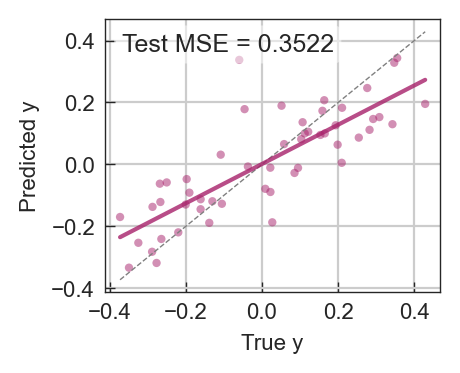

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


Alpha=0.01, MSE=0.3522


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


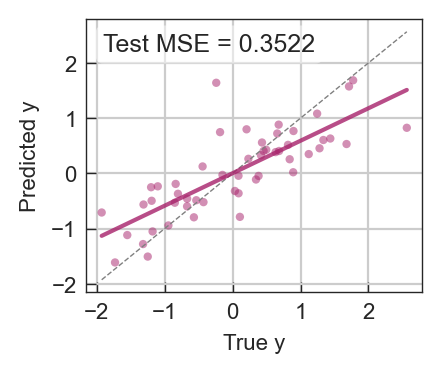

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


['P5-20', 'P5-18', 'P5-65', 'P5-77', 'P5-28', 'P5-82', 'P5-75', 'P5-40', 'P5-31', 'P5-79', 'P5-41', 'P5-24', 'P5-70', 'P5-16', 'P5-68', 'P5-15', 'P5-22', 'P5-26', 'P5-36', 'P5-67', 'P5-60', 'P5-19', 'P5-21', 'P5-27', 'P5-32', 'P5-81', 'P5-58', 'P5-78', 'P5-29', 'P5-34', 'P5-25', 'P5-66', 'P5-62', 'P5-80', 'P5-23', 'P5-71', 'P5-17', 'P5-38', 'P5-33', 'P5-72', 'P5-57', 'P5-37', 'P5-30', 'P5-74', 'P5-63', 'P5-76', 'P5-35']
Alpha=0.1, MSE=0.8511


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


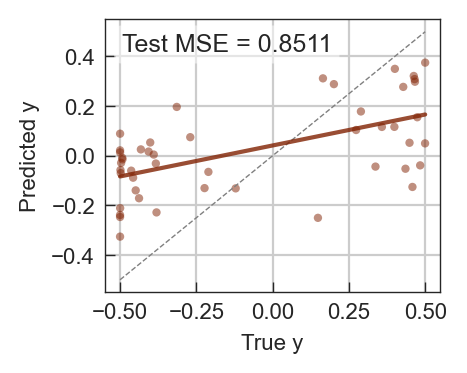

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


Alpha=0.1, MSE=0.8511


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


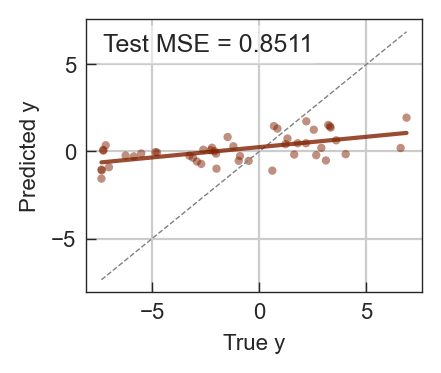

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


['P6-23', 'P6-35', 'P6-72', 'P6-71', 'P6-20', 'P6-56', 'P6-75', 'P6-65', 'P6-76', 'P6-17', 'P6-81', 'P6-82', 'P6-67', 'P6-62', 'P6-37', 'P6-41', 'P6-40', 'P6-16', 'P6-70', 'P6-28', 'P6-64', 'P6-31', 'P6-18', 'P6-61', 'P6-38', 'P6-27', 'P6-78', 'P6-66', 'P6-26', 'P6-34', 'P6-15', 'P6-19', 'P6-68', 'P6-29', 'P6-39', 'P6-77', 'P6-69', 'P6-25', 'P6-30', 'P6-73', 'P6-63', 'P6-21', 'P6-32', 'P6-36', 'P6-79', 'P6-60', 'P6-58', 'P6-59', 'P6-33', 'P6-80', 'P6-24', 'P6-22']
Alpha=0.063095, MSE=0.1903


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


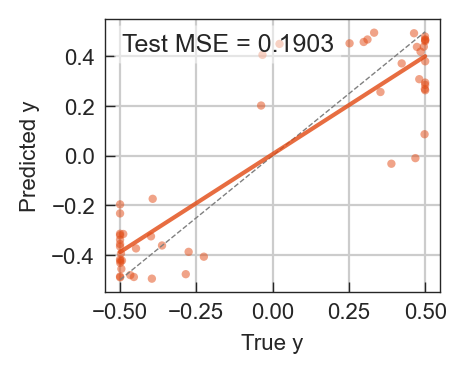

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


Alpha=0.063095, MSE=0.1903


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_38684/3342968638.py:80: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)


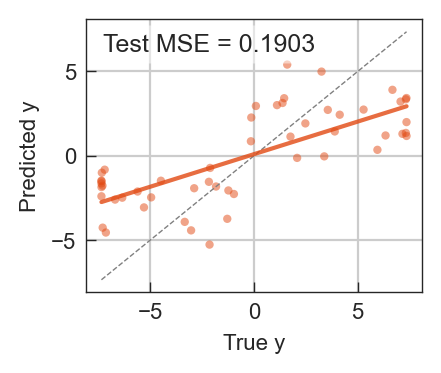

In [5]:
from scipy import stats


def plot_predictions_for_alpha(
    alpha,
    X1_all,
    X2_all,
    y_all,
    order,
    to_plot=False,
    save_filepath=None,
    scatter_color='blue',
    draw_reference_line=True,
    draw_shade=False,
    normalize=lambda x:x,
    confidence=0.95  # Confidence level for the shaded area
):
    # Duplicate X and y
    X1_train = X1_all
    X2_train = X2_all
    y_train  = y_all

    # -- FIT THE MODEL (using your custom function) --
    w_fit = fit_definite_strength_poly(
        X1_train, X2_train, y_train,
        order=order,
        alpha=[0.1, alpha]  # Adjust based on your function's requirements
    )

    # Predict on the original data
    y_pred = predict_ratio_poly(w_fit, X1_all, X2_all, order=order)

    # Compute the normalized MSE
    mse = np.mean((y_all - y_pred)**2) / np.var(y_all)

    print(f"Alpha={alpha}, MSE={mse:.4f}")

    if to_plot:
        # Fix random seed for reproducibility
        np.random.seed(43)

        N = len(y_all)
        # Choose random indices to flip (y -> -y)
        idx_to_flip = np.random.choice(N, size=N // 2, replace=False)

        # Copy and flip data for visualization
        y_all_flipped  = y_all.copy()
        y_pred_flipped = y_pred.copy()

        y_all_flipped[idx_to_flip]  = - y_all_flipped[idx_to_flip]
        y_pred_flipped[idx_to_flip] = - y_pred_flipped[idx_to_flip]

        # Recompute MSE based on flipped arrays (for what we'll actually see in the plot)
        mse_flipped = np.mean((y_all_flipped - y_pred_flipped)**2) / np.var(y_all_flipped)
        r_squared_flipped = 1 - mse_flipped  # Since mse_flipped = SS_res / SS_tot

        # ------------------------------------------------------------------------------
        # 3) PLOTTING
        # ------------------------------------------------------------------------------
        mm = 1 / 25.4 * 72
        fig_width  = 55 * mm
        fig_height = 45 * mm

        fig, ax = plt.subplots(
            figsize=(fig_width / 72, fig_height / 72),
            facecolor='w', edgecolor='k'
        )


        # Normalize the data
        y_true_norm = normalize(y_all_flipped)
        y_pred_norm = normalize(y_pred_flipped)

        # Plot flipped y vs flipped predictions
        ax.scatter(
            y_true_norm,
            y_pred_norm,
            alpha=0.5,
            color=scatter_color,
            edgecolor='none',
            label="Predicted vs True",
            s=9
        )

        # If requested, draw y=x in grey dashed style
        if draw_reference_line:
            min_val = min(y_true_norm.min(), y_pred_norm.min())
            max_val = max(y_true_norm.max(), y_pred_norm.max())
            ax.plot(
                [min_val, max_val],
                [min_val, max_val],
                color='grey',
                linestyle='--',
                label="Ideal Fit (y = x)",
                linewidth=0.5
            )

        # Conditionally draw the trend line and shaded confidence interval
        if draw_shade:
            # Compute linear regression for the trend line
            slope, intercept, r_value, p_value, std_err = stats.linregress(y_true_norm, y_pred_norm)
            y_fit = slope * y_true_norm + intercept

            # Calculate confidence intervals
            n = len(y_true_norm)
            dof = n - 2  # Degrees of freedom
            t_stat = stats.t.ppf((1 + confidence) / 2., dof)  # t-statistic for the confidence level
            residuals = y_pred_norm - y_fit
            s_err = np.sqrt(np.sum(residuals**2) / dof)  # Standard error of the estimate

            # Calculate the confidence interval
            ci = t_stat * s_err * np.sqrt(
                1/n + (y_true_norm - np.mean(y_true_norm))**2 / np.sum((y_true_norm - np.mean(y_true_norm))**2)
            )
            upper = y_fit + ci
            lower = y_fit - ci

            # **Important:** Sort the data for proper plotting
            sorted_indices = np.argsort(y_true_norm)
            y_true_sorted = y_true_norm[sorted_indices]
            y_fit_sorted = y_fit[sorted_indices]
            upper_sorted = upper[sorted_indices]
            lower_sorted = lower[sorted_indices]

            # Plot the trend line
            ax.plot(
                y_true_sorted,
                y_fit_sorted,
                color=scatter_color,
                label="Trend Line",
                linewidth=1.5,
                alpha=0.8  # Slightly higher alpha for the trend line
            )

            # Fill between the confidence intervals
            '''ax.fill_between(
                y_true_sorted,
                lower_sorted,
                upper_sorted,
                color=scatter_color,
                alpha=0.2,  # Higher alpha for shaded area
                label=f"{int(confidence*100)}% Confidence Interval"
            )'''



        # Add R-squared Text
        ax.text(
            0.05, 0.95,                # Position: (x, y) in axes coordinates
            f"Test MSE = {mse:.4f}",  # Formatted text with LaTeX for superscript
            transform=ax.transAxes,    # Position is relative to the axes
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.5)
        )

        # Additional Plot Settings
        ax.set_xlabel("True y")
        ax.set_ylabel("Predicted y")
        # ax.set_title(f"Alpha={alpha}")
        #ax.legend()
        ax.grid(True)

        # Save or show
        if save_filepath:
            fig.savefig(save_filepath, dpi=100, bbox_inches='tight')
            plt.show()
        else:
            plt.show()

    return y_pred, mse


    


medium_list=["L", "M", "H"]
alphas=[0.01, 0.1, 0.063095] #0.398107 is the minimum

for medium, alpha, color in zip(medium_list, alphas, colors):
    species_num=12
    com_type="S"
    rep=-1

    mode="Casewise" # "Communitywise"
    #mode="Casewise"

    if mode=="Casewise":
        degList=np.zeros(43)

        X1_all=[]
        X2_all=[]
        y_all=[]

        IDX_list = Community_PermutateList("F", com_type, medium, "C", species_num, rep)
        print(IDX_list)

        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
        data1=[]
        data2=[]
        data3=[]
        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            '''
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)
            '''
            u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
            data1.append(u)
            data2.append(v)
            data3.append(k)
            
            eps=1e-3
            y=(np.arctan(np.array(np.abs(u)+eps)/np.array(np.abs(v)+eps)))/(np.pi/2)-0.5
            X1_all.append(c_1)
            X2_all.append(c_2)
            y_all.append(y)

        X1_all=np.array(X1_all)
        X2_all=np.array(X2_all)
        y_all=np.array(y_all)
    else:
        degList=np.zeros(43)

        X_all={}
        y_all={}

        IDX_list = Community_PermutateList("F", com_type, medium, "C", species_num, rep)
        print(IDX_list)

        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            '''
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)
            '''
            u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
            print(u,v,k)
            eps=1e-9
            y=(np.arctan(np.array(np.abs(u)+eps)/np.array(np.abs(v)+eps)))/(np.pi/2)-0.5
            print(y)
            
            if idx_1[i] not in X_all:
                X_all[idx_1[i]]=[]
                y_all[idx_1[i]]=[]
            X_all[idx_1[i]]=c_1
            y_all[idx_1[i]].append(y)
            if idx_2[i] not in X_all:
                X_all[idx_2[i]]=[]
                y_all[idx_2[i]]=[]
            X_all[idx_2[i]]=c_2
            y_all[idx_2[i]].append(-y)
        X_all=np.array([list(item) for item in X_all.values()])
        y_all=np.array([np.mean(item) for item in y_all.values()])





    # Now running part

    # We do 5 random splits (80:20) to measure test accuracy
    n_splits = 10
    shuffle_split = ShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=123)

    # Suppose we want second-order fit with separate alpha for intercept, linear, quadratic
    # e.g. alpha = [0.01, 0.01, 0.01]
    order=1



        # Example normalization function (optional)
    def normalize(arr):
        return inv_sigmoid(arr)  # Replace with your actual normalization


    plot_predictions_for_alpha(
        alpha,
        X1_all,
        X2_all,
        y_all,
        order,
        to_plot=True,
        save_filepath=f"Figure/Fig_predictabiltiy_predictability_{medium}.svg",
        normalize=lambda x:x,
        scatter_color=color,
        draw_reference_line=True,
        draw_shade=True,
    )

    plot_predictions_for_alpha(
        alpha,
        X1_all,
        X2_all,
        y_all,
        order,
        to_plot=True,
        save_filepath=f"Figure/Fig_predictabiltiy_predictability_{medium}_normalized.svg",
        normalize=lambda x:normalize(x),
        scatter_color=color,
        draw_reference_line=True,
        draw_shade=True,
    )